In [ ]:
# IMPORTS & SETUP

import pandas as pd
import numpy as np

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.decomposition import PCA

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC

from sklearn.cluster import KMeans
from sklearn.metrics import accuracy_score, classification_report

import joblib
import warnings
warnings.filterwarnings("ignore")

print("Libraries imported successfully.")


Libraries imported successfully.


In [ ]:
#  LOAD DATA

df = pd.read_csv("/content/Metro_Interstate_Traffic_Volume[1].csv")
print("Dataset loaded successfully. Rows:", len(df))
df.head()


Dataset loaded successfully. Rows: 48204


,holiday,temp,rain_1h,snow_1h,clouds_all,weather_main,weather_description,date_time,traffic_volume
0,NaN,288.28,0.0,0.0,40,Clouds,scattered clouds,2012-10-02 09:00:00,5545
1,NaN,289.36,0.0,0.0,75,Clouds,broken clouds,2012-10-02 10:00:00,4516
2,NaN,289.58,0.0,0.0,90,Clouds,overcast clouds,2012-10-02 11:00:00,4767
3,NaN,290.13,0.0,0.0,90,Clouds,overcast clouds,2012-10-02 12:00:00,5026
4,NaN,291.14,0.0,0.0,75,Clouds,broken clouds,2012-10-02 13:00:00,4918


In [ ]:
#  DATA CLEANING

# Remove duplicates
df = df.drop_duplicates()

# Fill any missing values
df = df.fillna(0)

# Reset index
df = df.reset_index(drop=True)

print("Data cleaned. Final rows:", len(df))


Data cleaned. Final rows: 48187


In [ ]:
#  FEATURE ENGINEERING

df['date_time'] = pd.to_datetime(df['date_time'])

# Extract time-based features
df['hour'] = df['date_time'].dt.hour
df['dayofweek'] = df['date_time'].dt.dayofweek
df['month'] = df['date_time'].dt.month

print("Feature engineering completed.")
df[['date_time','hour','dayofweek','month']].head()


Feature engineering completed.


,date_time,hour,dayofweek,month
0,2012-10-02 09:00:00,9,1,10
1,2012-10-02 10:00:00,10,1,10
2,2012-10-02 11:00:00,11,1,10
3,2012-10-02 12:00:00,12,1,10
4,2012-10-02 13:00:00,13,1,10


In [ ]:
#  WEATHER SEVERITY MAPPING

weather_map = {
    'Clear': 0, 'Clouds': 1, 'Mist': 2, 'Fog': 2, 'Haze': 2,
    'Drizzle': 3, 'Rain': 3, 'Snow': 4, 'Thunderstorm': 5
}

df['weather_severity'] = df['weather_main'].map(weather_map).fillna(1)

print("Weather severity encoded.")
df[['weather_main','weather_severity']].head()


Weather severity encoded.


,weather_main,weather_severity
0,Clouds,1.0
1,Clouds,1.0
2,Clouds,1.0
3,Clouds,1.0
4,Clouds,1.0


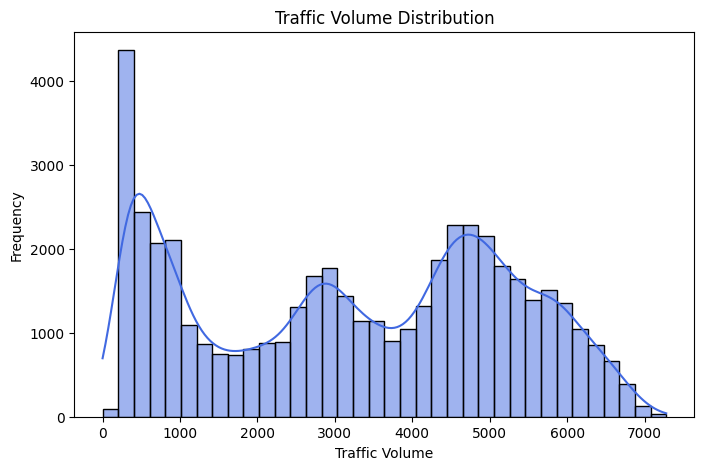

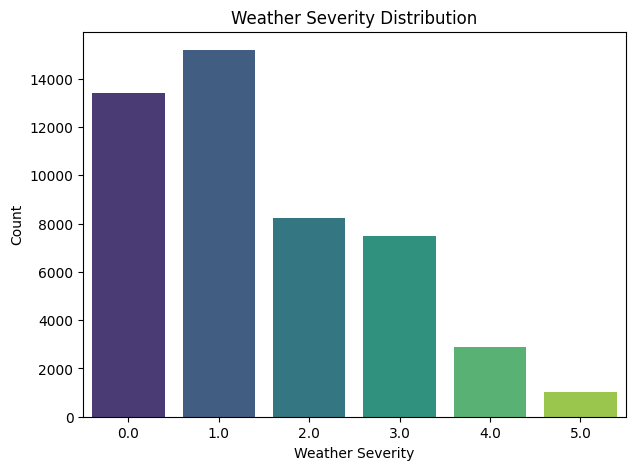

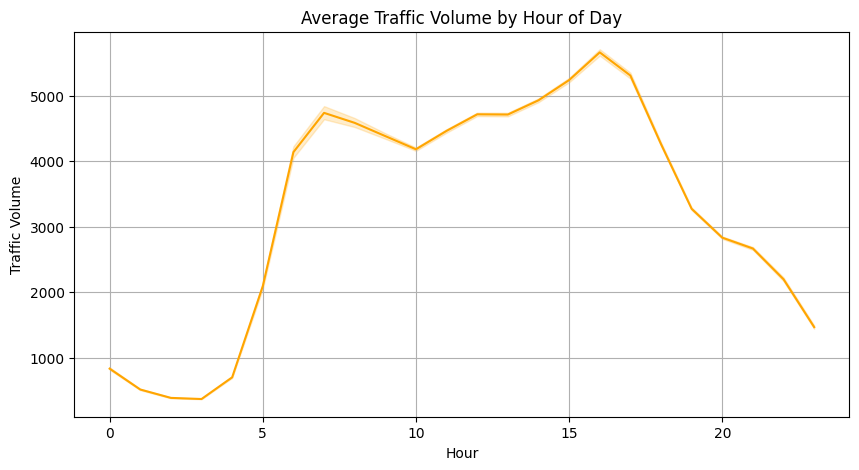

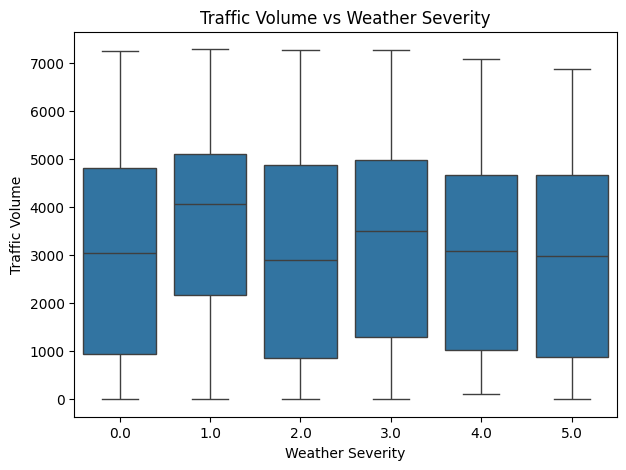

In [ ]:
plt.figure(figsize=(8,5))
sns.histplot(df['traffic_volume'], kde=True, color='royalblue')
plt.title("Traffic Volume Distribution")
plt.xlabel("Traffic Volume")
plt.ylabel("Frequency")
plt.show()

plt.figure(figsize=(7,5))
sns.countplot(x='weather_severity', data=df, palette='viridis')
plt.title("Weather Severity Distribution")
plt.xlabel("Weather Severity")
plt.ylabel("Count")
plt.show()

plt.figure(figsize=(10,5))
sns.lineplot(x='hour', y='traffic_volume', data=df, color='orange')
plt.title("Average Traffic Volume by Hour of Day")
plt.xlabel("Hour")
plt.ylabel("Traffic Volume")
plt.grid()
plt.show()

plt.figure(figsize=(7,5))
sns.boxplot(x='weather_severity', y='traffic_volume', data=df)
plt.title("Traffic Volume vs Weather Severity")
plt.xlabel("Weather Severity")
plt.ylabel("Traffic Volume")
plt.show()


In [ ]:
#  PCA RISK SCORING (UNSUPERVISED)

# Features used for PCA
pca_features = ['traffic_volume', 'weather_severity', 'clouds_all',
                'rain_1h', 'snow_1h']

# Scale features before PCA
scaler_pca = StandardScaler()
X_pca_scaled = scaler_pca.fit_transform(df[pca_features])

# Apply PCA to extract hidden patterns
pca = PCA(n_components=1)
df['risk_score'] = pca.fit_transform(X_pca_scaled).flatten()

# Convert continuous score into 3 categories
df['risk_label'] = pd.qcut(df['risk_score'], 3, labels=['Low', 'Medium', 'High'])

print("PCA risk scoring completed.")
df[['risk_score','risk_label']].head()


PCA risk scoring completed.


,risk_score,risk_label
0,-0.350495,Medium
1,0.250824,Medium
2,0.530029,Medium
3,0.538075,Medium
4,0.263312,Medium


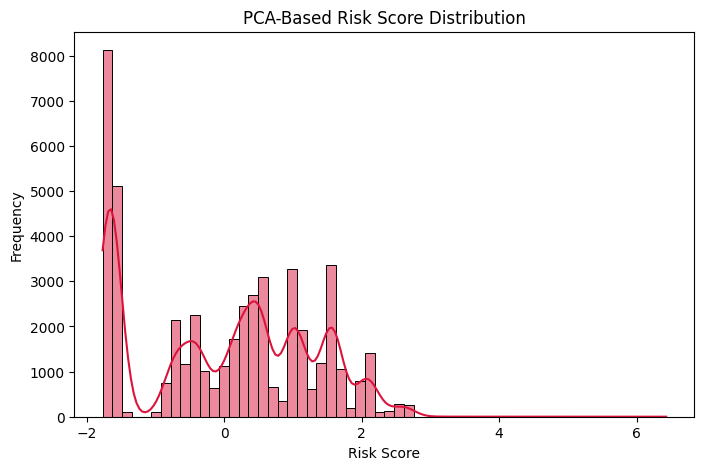

In [ ]:
plt.figure(figsize=(8,5))
sns.histplot(df['risk_score'], kde=True, color='crimson')
plt.title("PCA-Based Risk Score Distribution")
plt.xlabel("Risk Score")
plt.ylabel("Frequency")
plt.show()


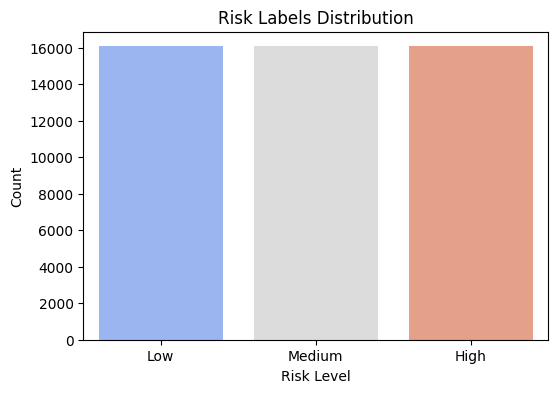

In [ ]:
plt.figure(figsize=(6,4))
sns.countplot(x='risk_label', data=df, palette='coolwarm')
plt.title("Risk Labels Distribution")
plt.xlabel("Risk Level")
plt.ylabel("Count")
plt.show()


In [ ]:
#  SUPERVISED LEARNING FEATURES

supervised_features = [
    'traffic_volume', 'weather_severity', 'clouds_all',
    'rain_1h', 'snow_1h', 'hour', 'dayofweek'
]

X = df[supervised_features]
y = df['risk_label']

print("Supervised features and labels prepared.")
X.head()


Supervised features and labels prepared.


,traffic_volume,weather_severity,clouds_all,rain_1h,snow_1h,hour,dayofweek
0,5545,1.0,40,0.0,0.0,9,1
1,4516,1.0,75,0.0,0.0,10,1
2,4767,1.0,90,0.0,0.0,11,1
3,5026,1.0,90,0.0,0.0,12,1
4,4918,1.0,75,0.0,0.0,13,1


In [ ]:
# TRAIN-TEST SPLIT + SCALING

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42, stratify=y
)

print("Train-test split completed.")


Train-test split completed.


In [ ]:
#  TRAINING SUPERVISED MODELS

# 1. Logistic Regression
log_clf = LogisticRegression(max_iter=300)
log_clf.fit(X_train, y_train)
log_pred = log_clf.predict(X_test)
log_acc = accuracy_score(y_test, log_pred)

# 2. Random Forest
rf_clf = RandomForestClassifier(random_state=42)
rf_clf.fit(X_train, y_train)
rf_pred = rf_clf.predict(X_test)
rf_acc = accuracy_score(y_test, rf_pred)

# 3. SVM
svm_clf = SVC(kernel='rbf')
svm_clf.fit(X_train, y_train)
svm_pred = svm_clf.predict(X_test)
svm_acc = accuracy_score(y_test, svm_pred)

print("Models trained successfully.")


Models trained successfully.


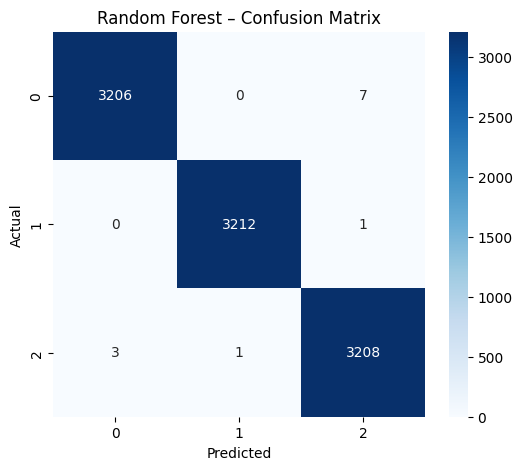

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

cm = confusion_matrix(y_test, rf_pred)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, cmap='Blues', fmt='g')
plt.title("Random Forest – Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()


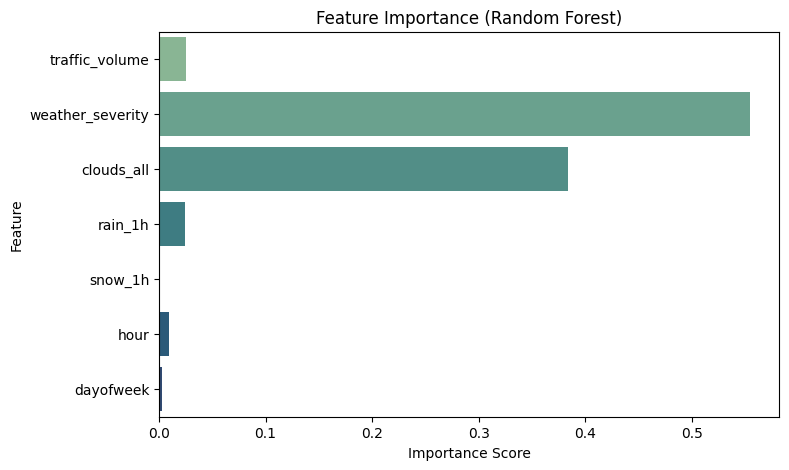

In [ ]:
plt.figure(figsize=(8,5))
importances = rf_clf.feature_importances_
sns.barplot(x=importances, y=supervised_features, palette='crest')
plt.title("Feature Importance (Random Forest)")
plt.xlabel("Importance Score")
plt.ylabel("Feature")
plt.show()


In [ ]:
# MODEL ACCURACY COMPARISON

results = pd.DataFrame({
    "Model": ["Logistic Regression", "Random Forest", "SVM"],
    "Accuracy": [log_acc, rf_acc, svm_acc]
})

print("\nMODEL ACCURACY COMPARISON:\n")
print(results)



MODEL ACCURACY COMPARISON:

                 Model  Accuracy
0  Logistic Regression  0.988587
1        Random Forest  0.998755
2                  SVM  0.990973


In [ ]:
#RANDOM FOREST REPORT

print("\nRANDOM FOREST CLASSIFICATION REPORT:\n")
print(classification_report(y_test, rf_pred))



RANDOM FOREST CLASSIFICATION REPORT:

              precision    recall  f1-score   support

        High       1.00      1.00      1.00      3213
         Low       1.00      1.00      1.00      3213
      Medium       1.00      1.00      1.00      3212

    accuracy                           1.00      9638
   macro avg       1.00      1.00      1.00      9638
weighted avg       1.00      1.00      1.00      9638



In [ ]:
#KMEANS HOTSPOT CLUSTERING

kmeans = KMeans(n_clusters=3, random_state=42)
df['cluster'] = kmeans.fit_predict(X_scaled)

print("\nSample hotspot cluster assignments:")
print(df[['traffic_volume','weather_severity','cluster']].head())



Sample hotspot cluster assignments:
   traffic_volume  weather_severity  cluster
0            5545               1.0        0
1            4516               1.0        1
2            4767               1.0        1
3            5026               1.0        1
4            4918               1.0        1


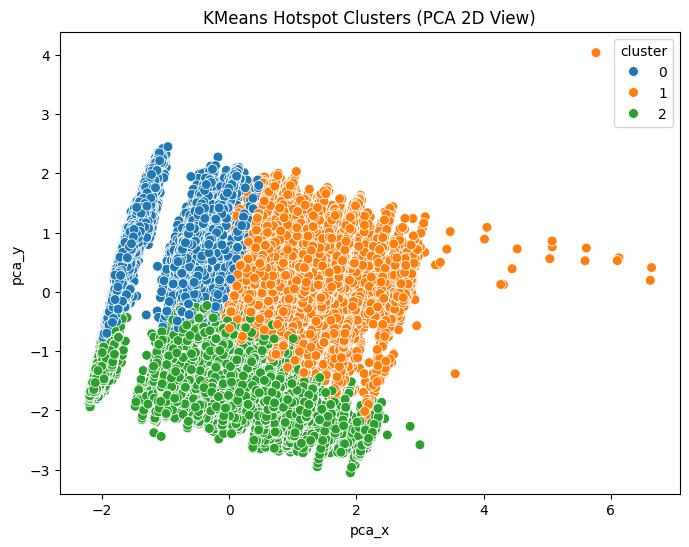

In [ ]:
pca_2d = PCA(n_components=2)
X_2d = pca_2d.fit_transform(X_scaled)

df['pca_x'] = X_2d[:,0]
df['pca_y'] = X_2d[:,1]

plt.figure(figsize=(8,6))
sns.scatterplot(
    x='pca_x', y='pca_y', hue='cluster',
    palette='tab10', data=df, s=50
)
plt.title("KMeans Hotspot Clusters (PCA 2D View)")
plt.show()


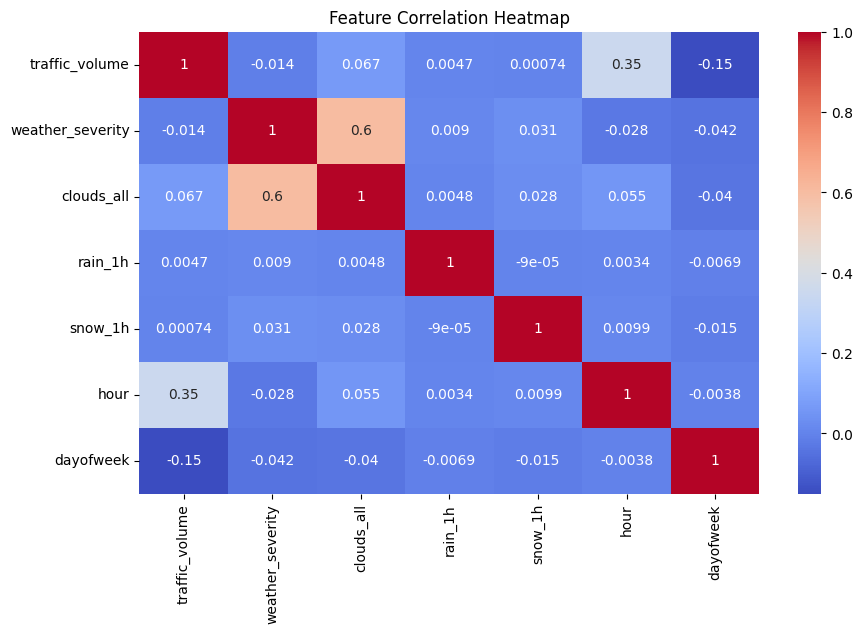

In [ ]:
plt.figure(figsize=(10,6))
sns.heatmap(df[supervised_features].corr(), annot=True, cmap="coolwarm")
plt.title("Feature Correlation Heatmap")
plt.show()


In [ ]:
#SAVE FINAL MODEL

joblib.dump(rf_clf, "risk_model.joblib")
joblib.dump(scaler, "scaler.joblib")

print("\nModel and scaler saved successfully!")



Model and scaler saved successfully!


In [ ]:
import joblib

joblib.dump(rf_clf, "risk_model.joblib")
joblib.dump(scaler, "scaler.joblib")
joblib.dump(kmeans, "kmeans.joblib")


['kmeans.joblib']